In [1]:
from trading_tda.config import RAW_DATA_DIR as raw_dir

In [2]:
from trading_tda.h5_utils import print_hdf5_structure

In [3]:
for item in raw_dir.rglob("BTC*.feather"):
    print(item)

/home/isaul/projects/trading-tda/data/raw/binance/BTC_USDT-15m.feather
/home/isaul/projects/trading-tda/data/raw/binance/BTC_USDT-4h.feather


In [4]:
import pandas as pd

In [5]:
from trading_tda.data import load_freqtrade_ohlc

In [6]:
from trading_tda.data import filter_dataframe_by_timerange

In [7]:
pair = "BTC_USDT"
timeframe = "4h"
timerange = "20250501-20260501"
window_size = 64
stride = 1
dimension = 3
delay = 1
btc = (
    load_freqtrade_ohlc(pairs=[pair], timeframe=timeframe)
    .xs(pair, axis=1, level="pair")
)

btc = filter_dataframe_by_timerange(btc, timerange=timerange)

In [8]:
btc.head()

price,close,high,low,open,volume
date,,,,,
2025-05-01 00:00:00+00:00,94782.60,95040.30,94130.43,94172.00,2877.43780
2025-05-01 04:00:00+00:00,95025.84,95180.00,94714.38,94782.60,1880.34885
2025-05-01 08:00:00+00:00,96180.01,96396.31,94913.04,95025.84,4237.08588
2025-05-01 12:00:00+00:00,96854.30,97424.02,95769.66,96180.01,7399.49215
2025-05-01 16:00:00+00:00,96523.26,97367.26,96424.44,96854.31,3200.80242


In [9]:
btc.index.min()

Timestamp('2025-05-01 00:00:00+0000', tz='UTC')

In [10]:
btc.index.max()

Timestamp('2026-05-01 20:00:00+0000', tz='UTC')

In [11]:
btc.shape

(2196, 5)

In [12]:
n, m = btc.shape

In [13]:
close = btc["close"].values
volume = btc["volume"].values

In [14]:
btc.index.dtype

datetime64[ms, UTC]

In [15]:
timestamps = btc.index.view("int64")

In [16]:
timestamps[:10]

array([1746057600000, 1746072000000, 1746086400000, 1746100800000,
       1746115200000, 1746129600000, 1746144000000, 1746158400000,
       1746172800000, 1746187200000])

In [17]:
pd.to_datetime(timestamps[0], utc=True, unit="ms")

Timestamp('2025-05-01 00:00:00+0000', tz='UTC')

In [18]:
pd.to_datetime(timestamps[1], utc=True, unit="ms")

Timestamp('2025-05-01 04:00:00+0000', tz='UTC')

## hdf5

In [19]:
import numpy as np

In [20]:
import h5py

In [21]:
from trading_tda.config import PROCESSED_DATA_DIR as processed_dir

In [22]:
for item in processed_dir.rglob("*.h5"): 
    print(item)

/home/isaul/projects/trading-tda/data/processed/BTC_USDT_4h_20250501-20260501_tda.h5
/home/isaul/projects/trading-tda/data/processed/BTC_USDT_4h_20250501-20260501_tda_temp.h5


In [23]:
p = processed_dir / "BTC_USDT_4h_20250501-20260501_tda.h5"

p.is_file()

True

In [24]:
from trading_tda.h5_utils import print_hdf5_structure

La estructura general final: 

In [25]:
print_hdf5_structure(p)

[GROUP] features
    [GROUP] features/w64
        [GROUP] features/w64/d3_t1
            [GROUP] features/w64/d3_t1/persistence_entropy
                [GROUP] features/w64/d3_t1/persistence_entropy/h0
                    [DATASET] features/w64/d3_t1/persistence_entropy/h0/close shape=(2133, 1)
                    [DATASET] features/w64/d3_t1/persistence_entropy/h0/volume shape=(2133, 1)
                [GROUP] features/w64/d3_t1/persistence_entropy/h1
                    [DATASET] features/w64/d3_t1/persistence_entropy/h1/close shape=(2133, 1)
                    [DATASET] features/w64/d3_t1/persistence_entropy/h1/volume shape=(2133, 1)
            [GROUP] features/w64/d3_t1/persistence_statistics
                [GROUP] features/w64/d3_t1/persistence_statistics/h0
                    [DATASET] features/w64/d3_t1/persistence_statistics/h0/close shape=(2133, 6)
                    [DATASET] features/w64/d3_t1/persistence_statistics/h0/volume shape=(2133, 6)
                [GROUP] feat

Cargamos el archivo:

In [26]:
f = h5py.File(p, "r")

In [27]:
def print_kvd(d: dict):
    for key, value in d.items():
        print(f"{key:<15} -> {value}")

Los atributos base: 

In [28]:
print_kvd(f.attrs)

asset           -> BTC_USDT
created_at      -> 2026-05-22T17:39:36.603246
exchange        -> binance
timeframe       -> 20250501-20260501


Los grupos base: 

In [29]:
print_kvd(f)

features        -> <HDF5 group "/features" (1 members)>
persistence     -> <HDF5 group "/persistence" (1 members)>
raw             -> <HDF5 group "/raw" (3 members)>
takens          -> <HDF5 group "/takens" (1 members)>
vectorization   -> <HDF5 group "/vectorization" (2 members)>
windows         -> <HDF5 group "/windows" (1 members)>


## raw

La estructura: 
```text
[GROUP] raw
    [DATASET] raw/close shape=(2196,)
    [DATASET] raw/timestamps shape=(2196,)
    [DATASET] raw/volume shape=(2196,)

In [30]:
raw_group = f["raw"]

In [31]:
print_kvd(raw_group)

close           -> <HDF5 dataset "close": shape (2196,), type "<f4">
timestamps      -> <HDF5 dataset "timestamps": shape (2196,), type "<i8">
volume          -> <HDF5 dataset "volume": shape (2196,), type "<f4">


In [32]:
raw_close = raw_group["close"][:]
raw_volume = raw_group["volume"][:]
raw_timestamps = raw_group["timestamps"][:]

In [33]:
assert np.allclose(raw_close, close)

In [34]:
assert np.allclose(raw_volume, volume)

In [35]:
raw_volume

array([2877.4377, 1880.3489, 4237.086 , ..., 6731.1953, 2194.4258,
       1818.7882], shape=(2196,), dtype=float32)

In [36]:
volume

array([2877.4378 , 1880.34885, 4237.08588, ..., 6731.19551, 2194.42574,
       1818.78817], shape=(2196,))

In [37]:
assert np.allclose(raw_timestamps, timestamps)

In [38]:
# from trading_tda.loaders import load_raw

### windows

La estructura: 

```text
[GROUP] windows
    [GROUP] windows/w64
        [DATASET] windows/w64/close shape=(2133, 64)
        [DATASET] windows/w64/timestamp shape=(2133,)
        [DATASET] windows/w64/volume shape=(2133, 64)
```

In [39]:
windows_group = f["windows"]

In [40]:
print_kvd(windows_group)

w64             -> <HDF5 group "/windows/w64" (3 members)>


#### Data

Las ventanas para dados son completas. 

In [41]:
close_w64 = windows_group["w64/close"][:]

In [42]:
close_w64.shape

(2133, 64)

In [43]:
close_w64[0]

array([ 94782.6 ,  95025.84,  96180.01,  96854.3 ,  96523.26,  96489.91,
        97102.32,  96350.  ,  96928.97,  97330.19,  96924.23,  96887.14,
        96337.5 ,  96322.68,  95942.02,  96418.68,  96354.34,  95856.42,
        95722.23,  95879.99,  95423.2 ,  95467.6 ,  95584.07,  94277.62,
        94031.47,  94761.91,  94038.18,  93770.31,  94347.17,  94733.68,
        94454.01,  94400.99,  93812.54,  94558.95,  94963.5 ,  96834.02,
        96506.9 ,  96994.82,  97047.43,  96923.91,  96180.01,  97030.5 ,
        99152.79,  99252.34,  99409.14, 100758.08, 101299.99, 103261.6 ,
       102451.04, 103628.77, 102958.31, 102895.99, 103189.17, 102971.99,
       103226.24, 103759.71, 103434.94, 103138.77, 103191.35, 104809.53,
       104007.03, 103385.47, 104652.01, 104150.  ], dtype=float32)

In [44]:
raw_close[:64]

array([ 94782.6 ,  95025.84,  96180.01,  96854.3 ,  96523.26,  96489.91,
        97102.32,  96350.  ,  96928.97,  97330.19,  96924.23,  96887.14,
        96337.5 ,  96322.68,  95942.02,  96418.68,  96354.34,  95856.42,
        95722.23,  95879.99,  95423.2 ,  95467.6 ,  95584.07,  94277.62,
        94031.47,  94761.91,  94038.18,  93770.31,  94347.17,  94733.68,
        94454.01,  94400.99,  93812.54,  94558.95,  94963.5 ,  96834.02,
        96506.9 ,  96994.82,  97047.43,  96923.91,  96180.01,  97030.5 ,
        99152.79,  99252.34,  99409.14, 100758.08, 101299.99, 103261.6 ,
       102451.04, 103628.77, 102958.31, 102895.99, 103189.17, 102971.99,
       103226.24, 103759.71, 103434.94, 103138.77, 103191.35, 104809.53,
       104007.03, 103385.47, 104652.01, 104150.  ], dtype=float32)

In [45]:
assert np.allclose(close_w64[0], raw_close[:64])
assert np.allclose(close_w64[1], raw_close[1:65])
assert np.allclose(close_w64[2], raw_close[2:66])

In [46]:
from trading_tda.loaders import load_window_dataset

In [47]:
load_window_dataset?

Signature:
load_window_dataset(
    h5_path: pathlib.Path,
    signal_name: str,
    window_size: int,
)
Docstring: <no docstring>
File:      ~/projects/trading-tda/src/trading_tda/loaders.py
Type:      function

In [48]:
assert np.allclose(
    close_w64, 
    load_window_dataset(
        h5_path=p, 
        signal_name="close", 
        window_size=window_size
    )
)

#### timestamps

In [49]:
timestamps_w64 = windows_group["w64/timestamp"][:]

In [50]:
assert len(timestamps_w64) == len(close_w64)

El windowing en `timestamps` no es completo, no contiene ventanas de timestamps. 

El `timestamp`guardado reprecenta el último timestamp de cada ventana. 

La ventana es de tamaño 64, por lo tanto, el primer *window timestamp* debe coincidir con el timestamp original en la posición 63. 

In [51]:
pd.to_datetime(timestamps_w64[0], unit="ms"), btc.index[63]

(Timestamp('2025-05-11 12:00:00'),
 Timestamp('2025-05-11 12:00:00+0000', tz='UTC'))

In [52]:
assert timestamps_w64[0] == raw_timestamps[63]

El segundo timestamp: 

In [53]:
assert timestamps_w64[1] == raw_timestamps[64]

En general: 

In [54]:
i = 100

assert np.allclose(
    close_w64[i], 
    close[i: i+64]
)

assert timestamps_w64[i] == raw_timestamps[i+63]

In [55]:
close_w64.shape, timestamps_w64.shape

((2133, 64), (2133,))

In [56]:
assert np.allclose(
    timestamps_w64, 
    load_window_dataset(
        h5_path=p, 
        signal_name="timestamp", 
        window_size=window_size
    )
)

### takens

La estructura:
```text
[GROUP] takens
    [GROUP] takens/w64
        [GROUP] takens/w64/d3_t1
            [DATASET] takens/w64/d3_t1/close shape=(2133, 62, 3)
            [DATASET] takens/w64/d3_t1/volume shape=(2133, 62, 3)
```

In [57]:
takens_group = f["takens"]

In [58]:
print_kvd(takens_group)

w64             -> <HDF5 group "/takens/w64" (1 members)>


In [59]:
close_takens_w64 = takens_group["w64/d3_t1/close"][:]

In [60]:
close_takens_w64[0]; 

In [61]:
from trading_tda.loaders import load_takens_embeddings

In [62]:
load_takens_embeddings?

Signature:
load_takens_embeddings(
    h5_path: pathlib.Path,
    signal_name: str,
    window_size: int,
    dimension: int,
    delay: int,
)
Docstring: Carga Takens embeddings desde HDF5.
File:      ~/projects/trading-tda/src/trading_tda/loaders.py
Type:      function

In [63]:
assert np.allclose(
    close_takens_w64, 
    load_takens_embeddings(
        h5_path=p, 
        signal_name="close", 
        window_size=window_size, 
        dimension=dimension, 
        delay=delay
    )
)

### persistence


```text
[GROUP] persistence
    [GROUP] persistence/w64
        [GROUP] persistence/w64/d3_t1
            [GROUP] persistence/w64/d3_t1/h0
                [DATASET] persistence/w64/d3_t1/h0/close shape=(2133, 62, 2)
                [DATASET] persistence/w64/d3_t1/h0/volume shape=(2133, 62, 2)
            [GROUP] persistence/w64/d3_t1/h1
                [DATASET] persistence/w64/d3_t1/h1/close shape=(2133, 21, 2)
                [DATASET] persistence/w64/d3_t1/h1/volume shape=(2133, 26, 2)

In [64]:
persistence_group = f["persistence"]

In [65]:
print_kvd(persistence_group)

w64             -> <HDF5 group "/persistence/w64" (1 members)>


In [66]:
persistence_w64 = persistence_group["w64"]

In [67]:
print_kvd(persistence_w64)

d3_t1           -> <HDF5 group "/persistence/w64/d3_t1" (2 members)>


In [68]:
from trading_tda.loaders import load_persistence

In [69]:
close_h0 = load_persistence(
    h5_path=p, 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay, 
    homology_dim=0
)

close_h1 = load_persistence(
    h5_path=p, 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay, 
    homology_dim=1
)

In [74]:
import matplotlib.pyplot as plt

In [75]:
from ipywidgets import interact
from persim import plot_diagrams

In [76]:
def plot_diagram(i):
    plot_diagrams(
        [close_h0[i], close_h1[i]]
    )
    plt.show()

interact(plot_diagram, i=(0, len(close_h0)-1, 1))

interactive(children=(IntSlider(value=1066, description='i', max=2132), Output()), _dom_classes=('widget-inter…

<function __main__.plot_diagram(i)>

---

In [80]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from ipywidgets import widgets

In [81]:
def plot_all(
    series,
    embedding,
    h0,
    h1,
    timestamps=None,
    title="Takens Embedding",
    cmap="viridis"
):

    fig = plt.figure(figsize=(14, 8))

    gs = GridSpec(
        2,
        2,
        height_ratios=[1, 1.2],
        figure=fig
    )

    ax_ts = fig.add_subplot(gs[0, :])

    if timestamps is not None:
        ax_ts.plot(timestamps, series)
    else:
        ax_ts.plot(series)

    ax_ts.set_title("Time series")

    ax_ts.set_xlabel("Time")
    ax_ts.set_ylabel("x(t)")

    ax_ts.grid(alpha=0.3)

    ax_emb = fig.add_subplot(gs[1, 0], projection="3d")

    colors = np.arange(len(embedding))

    scatter = ax_emb.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=colors,
        cmap=cmap,
        s=8,
        alpha=0.8
    )

    ax_emb.set_title(title)

    ax_emb.set_xlabel("x(t)")
    ax_emb.set_ylabel(r"x(t+\tau)")
    ax_emb.set_zlabel(r"x(t+2\tau)")

    cbar = fig.colorbar(
        scatter,
        ax=ax_emb,
        shrink=0.7
    )

    cbar.set_label("Temporal evolution")

    ax_pd = fig.add_subplot(gs[1, 1])

    plot_diagrams(
        [h0, h1],
        ax=ax_pd,
        show=False
    )

    ax_pd.set_title("Persistence Diagram")

    plt.tight_layout()
    plt.show()


In [82]:
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(close_w64)-1,
    step=1,
    description='i'
)

play = widgets.Play(
    value=0,
    min=0,
    max=len(close_w64)-1,
    step=1,
    interval=1000,
    description="Play",
    disabled=False
)

widgets.jslink((play, 'value'), (slider, 'value'))


def show(i):

    w_ts = pd.to_datetime(
        raw_timestamps[i:i+window_size],
        unit="ms"
    )

    plot_all(
        series=close_w64[i],
        embedding=close_takens_w64[i],
        h0=close_h0[i],
        h1=close_h1[i],
        timestamps=w_ts
    )


ui = widgets.HBox([play, slider])

out = widgets.interactive_output(
    show,
    {'i': slider}
)

display(ui, out)

Output()

---

### Vectorization

```text
[GROUP] vectorization
    [GROUP] vectorization/betti_curve
        [GROUP] vectorization/betti_curve/w64
            [GROUP] vectorization/betti_curve/w64/d3_t1
                [GROUP] vectorization/betti_curve/w64/d3_t1/h0
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h0/close shape=(2133, 100)
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h0/t shape=(100,)
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h0/volume shape=(2133, 100)
                [GROUP] vectorization/betti_curve/w64/d3_t1/h1
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h1/close shape=(2133, 100)
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h1/t shape=(100,)
                    [DATASET] vectorization/betti_curve/w64/d3_t1/h1/volume shape=(2133, 100)
    [GROUP] vectorization/persistence_vectors
        [GROUP] vectorization/persistence_vectors/w64
            [GROUP] vectorization/persistence_vectors/w64/d3_t1
                [GROUP] vectorization/persistence_vectors/w64/d3_t1/h0
                    [DATASET] vectorization/persistence_vectors/w64/d3_t1/h0/close shape=(2133, 62)
                    [DATASET] vectorization/persistence_vectors/w64/d3_t1/h0/volume shape=(2133, 62)
                [GROUP] vectorization/persistence_vectors/w64/d3_t1/h1
                    [DATASET] vectorization/persistence_vectors/w64/d3_t1/h1/close shape=(2133, 21)
                    [DATASET] vectorization/persistence_vectors/w64/d3_t1/h1/volume shape=(2133, 26)
```

In [83]:
vectorization_group = f["vectorization"]

In [84]:
print_kvd(vectorization_group)

betti_curve     -> <HDF5 group "/vectorization/betti_curve" (1 members)>
persistence_vectors -> <HDF5 group "/vectorization/persistence_vectors" (1 members)>


#### Persistence vectors

In [85]:
from trading_tda.loaders import load_vectorization

In [86]:
load_vectorization?

Signature:
load_vectorization(
    h5_path: pathlib.Path,
    vectorization_type: str,
    signal_name: str,
    window_size: int,
    dimension: int,
    delay: int,
    homology_dim: int,
)
Docstring: Carga vectorizaciones desde HDF5.
File:      ~/projects/trading-tda/src/trading_tda/loaders.py
Type:      function

In [87]:
close_pv_h0 = load_vectorization(
    h5_path=p, 
    vectorization_type="persistence_vectors", 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay,
    homology_dim=0
)

close_pv_h1 = load_vectorization(
    h5_path=p, 
    vectorization_type="persistence_vectors", 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay,
    homology_dim=1
)

In [88]:
close_pv_h0.shape

(2133, 62)

In [89]:
close_pv_h0[0]

array([       inf, 2441.5598 , 2288.5276 , 2190.5693 , 2130.401  ,
       1833.3256 , 1462.152  , 1361.664  , 1334.5312 , 1310.3627 ,
       1220.7672 , 1210.2771 , 1154.4961 , 1070.6553 , 1063.5582 ,
        980.13354,  903.53015,  895.2579 ,  743.17487,  718.8819 ,
        694.0042 ,  674.3217 ,  662.3214 ,  629.60223,  625.6356 ,
        610.1803 ,  599.7599 ,  598.1833 ,  579.33215,  539.2815 ,
        524.3385 ,  522.85583,  515.74286,  508.15237,  506.05685,
        505.58566,  501.55222,  485.30142,  484.8636 ,  480.01593,
        477.7211 ,  473.48962,  442.6685 ,  433.0946 ,  422.21713,
        400.66013,  396.70605,  370.1421 ,  359.1683 ,  330.0084 ,
        329.2723 ,  323.01947,  317.70544,  315.35974,  299.05533,
        290.32483,  287.98468,  266.52863,  252.09006,  245.8582 ,
        203.30891,  122.14902], dtype=float32)

In [90]:
np.isinf(close_pv_h0).any()

np.True_

In [91]:
np.isinf(close_pv_h1).any()

np.False_

In [92]:
m0, n0 = close_pv_h0.shape

In [93]:
mask_finite = np.isfinite(close_pv_h0)
valid = close_pv_h0[mask_finite]

In [94]:
mask_finite.shape

(2133, 62)

In [95]:
valid.shape

(130113,)

In [96]:
mask_finite.sum(axis=1)

array([61, 61, 61, ..., 61, 61, 61], shape=(2133,))

In [97]:
valid = valid.reshape(m0, n0-1)

In [98]:
assert np.allclose(
    close_pv_h0[:, 1:], 
    valid
)

In [99]:
close_pv_h0_mean = np.mean(valid, axis=1)
close_pv_h0_std = np.std(valid, axis=1)
close_pv_h0_max = np.max(valid, axis=1)
close_pv_h0_min = np.min(valid, axis=1)
close_pv_h0_sum = np.sum(valid, axis=1)
close_pv_h0_median = np.median(valid, axis=1)
close_pv_h0_count = np.size(valid, axis=1)

In [100]:
stats = np.column_stack([
    close_pv_h0_mean, 
    close_pv_h0_std, 
    close_pv_h0_max, 
    close_pv_h0_min, 
    close_pv_h0_sum,
    close_pv_h0_median,
])

In [101]:
names = [
    "total_persistence",
    "mean_persistence", 
    "std_persistence", 
    "median_persistence",
    "max_persistence",
    "min_persistence",
]

In [102]:
pd.DataFrame(stats, columns=names)

,total_persistence,mean_persistence,std_persistence,median_persistence,max_persistence,min_persistence
0,736.384338,536.625305,2441.559814,122.149017,44919.445312,522.855835
1,744.437805,539.794373,2441.559814,122.149017,45410.707031,522.855835
2,741.948303,543.850952,2441.559814,122.149017,45258.847656,522.855835
3,735.471436,543.556824,2441.559814,122.149017,44863.757812,515.742859
4,739.084656,538.170593,2441.559814,122.149017,45084.164062,539.281494
...,...,...,...,...,...,...
2128,447.319031,238.133881,1294.977905,81.457573,27286.460938,368.948914
2129,445.079498,247.122421,1294.977905,81.457573,27149.849609,356.645721
2130,453.820770,246.770309,1294.977905,81.457573,27683.066406,368.948914
2131,457.083191,253.098358,1409.648926,81.457573,27882.074219,399.717255


In [103]:
close_pv_h1[0]

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
       179.42542 , 142.11462 , 124.38507 ,  82.877014,  76.778625,
        56.48242 ,  47.026   ,  38.01831 ,  26.482788,  21.402649,
        21.316162], dtype=float32)

In [104]:
close_pv_h1.mean(axis=1)

array([nan, nan, nan, ..., nan, nan, nan], shape=(2133,), dtype=float32)

#### Betti curves

In [105]:
close_betti_h0 = load_vectorization(
    h5_path=p, 
    vectorization_type="betti_curve", 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay,
    homology_dim=0
)

close_betti_h1 = load_vectorization(
    h5_path=p, 
    vectorization_type="betti_curve", 
    signal_name="close", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay,
    homology_dim=1
)

t = load_vectorization(
    h5_path=p, 
    vectorization_type="betti_curve", 
    signal_name="t", 
    window_size=window_size, 
    dimension=dimension, 
    delay=delay,
    homology_dim=0
)

In [106]:
t.shape

(100,)

In [107]:
close_betti_h0.shape

(2133, 100)

In [108]:
close_betti_h1.shape

(2133, 100)

In [109]:
from gtda.plotting import plot_betti_curves

In [110]:
from trading_tda.tda import to_gtda_format

In [111]:
def plot_bettis(i):
    fig, ax = plt.subplots(1,2, figsize=(12,6))
    ax[0].plot(t, close_betti_h0[i])
    ax[1].plot(t, close_betti_h1[i])
    plt.show()
    
interact(plot_bettis, i=(0, len(close_betti_h0)-1, 1))

interactive(children=(IntSlider(value=1066, description='i', max=2132), Output()), _dom_classes=('widget-inter…

<function __main__.plot_bettis(i)>

### Features

La estructura: 
```
[GROUP] features
    [GROUP] features/w64
        [GROUP] features/w64/d3_t1
            [GROUP] features/w64/d3_t1/persistence_entropy
                [GROUP] features/w64/d3_t1/persistence_entropy/h0
                    [DATASET] features/w64/d3_t1/persistence_entropy/h0/close shape=(2133, 1, 1)
                    [DATASET] features/w64/d3_t1/persistence_entropy/h0/volume shape=(2133, 1, 1)
                [GROUP] features/w64/d3_t1/persistence_entropy/h1
                    [DATASET] features/w64/d3_t1/persistence_entropy/h1/close shape=(2133, 1, 1)
                    [DATASET] features/w64/d3_t1/persistence_entropy/h1/volume shape=(2133, 1, 1)
            [GROUP] features/w64/d3_t1/persistence_statistics
                [GROUP] features/w64/d3_t1/persistence_statistics/h0
                    [DATASET] features/w64/d3_t1/persistence_statistics/h0/close shape=(2133, 6)
                    [DATASET] features/w64/d3_t1/persistence_statistics/h0/volume shape=(2133, 6)
                [GROUP] features/w64/d3_t1/persistence_statistics/h1
                    [DATASET] features/w64/d3_t1/persistence_statistics/h1/close shape=(2133, 6)
                    [DATASET] features/w64/d3_t1/persistence_statistics/h1/volume shape=(2133, 6)

```

In [112]:
from trading_tda.loaders import load_feature

In [113]:
load_feature?

Signature:
load_feature(
    h5_path: pathlib.Path,
    feature_name: str,
    signal_name: str,
    window_size: int,
    dimension: int,
    delay: int,
    homology_dim: int,
)
Docstring: Carga features topológicas desde HDF5.
File:      ~/projects/trading-tda/src/trading_tda/loaders.py
Type:      function

Persistent entropy: 

In [114]:
close_pe_h0 = load_feature(
    h5_path=p,
    window_size=window_size,
    dimension=dimension, 
    delay=delay, 
    feature_name="persistence_entropy", 
    homology_dim=0, 
    signal_name="close"
)

close_pe_h1 = load_feature(
    h5_path=p,
    window_size=window_size,
    dimension=dimension, 
    delay=delay, 
    feature_name="persistence_entropy", 
    homology_dim=1, 
    signal_name="close"
)

In [115]:
close_pe_h0.shape

(2133, 1)

In [116]:
close_pe_h1.shape

(2133, 1)

Persistence statistics

In [117]:
close_stats_h0 = load_feature(
    h5_path=p,
    window_size=window_size,
    dimension=dimension, 
    delay=delay, 
    feature_name="persistence_statistics", 
    homology_dim=0, 
    signal_name="close"
)

close_stats_h1 = load_feature(
    h5_path=p,
    window_size=window_size,
    dimension=dimension, 
    delay=delay, 
    feature_name="persistence_statistics", 
    homology_dim=1, 
    signal_name="close"
)

In [118]:
close_stats_h0.shape

(2133, 6)

In [119]:
close_stats_h1.shape

(2133, 6)

In [120]:
close_stats_h1

array([[ 816.3091  ,   38.87186 ,   52.260647,   21.316162,  179.42542 ,
           0.      ],
       [1091.3308  ,   51.968132,   90.14681 ,   21.316162,  402.33704 ,
           0.      ],
       [1141.5347  ,   54.358795,   86.17451 ,   21.316162,  339.14    ,
           0.      ],
       ...,
       [ 917.94336 ,   43.71159 ,   62.910675,   11.368774,  212.4461  ,
           0.      ],
       [ 908.5227  ,   43.262985,   63.18658 ,   11.368774,  212.4461  ,
           0.      ],
       [ 837.9232  ,   39.901104,   59.86319 ,   11.368774,  212.4461  ,
           0.      ]], shape=(2133, 6), dtype=float32)

In [121]:
tda_features = np.column_stack([
    close_pe_h0,
    close_pe_h1,
    close_stats_h0,
    close_stats_h1, 
])

Alineamos las features con los datos raw: 

In [122]:
pad_rows = window_size - 1
pad_columns = tda_features.shape[1]

pad_arr = np.full(
    (pad_rows, pad_columns), 
    fill_value=np.nan
)

print(pad_arr.shape)

(63, 14)


In [123]:
aligned_tda_features = np.vstack([
    pad_arr, 
    tda_features
])

aligned_tda_features.shape

(2196, 14)

In [124]:
tda_features_df = pd.DataFrame(
    aligned_tda_features, 
    columns=[
        "close_persistent_entropy_h0", 
        "close_persistent_entropy_h1", 
        "close_total_persistence_h0",
        "close_mean_persistence_h0", 
        "close_std_persistence_h0", 
        "close_median_persistence_h0",
        "close_max_persistence_h0",
        "close_min_persistence_h0",
        "close_total_persistence_h1",
        "close_mean_persistence_h1", 
        "close_std_persistence_h1", 
        "close_median_persistence_h1",
        "close_max_persistence_h1",
        "close_min_persistence_h1",
    ],
)
tda_features_df.head()

,close_persistent_entropy_h0,close_persistent_entropy_h1,close_total_persistence_h0,close_mean_persistence_h0,close_std_persistence_h0,close_median_persistence_h0,close_max_persistence_h0,close_min_persistence_h0,close_total_persistence_h1,close_mean_persistence_h1,close_std_persistence_h1,close_median_persistence_h1,close_max_persistence_h1,close_min_persistence_h1
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
close_df = pd.DataFrame(
    np.column_stack([
        raw_timestamps, 
        raw_close
    ]), 
    columns=["timestamp", "close"], 
)
close_df.head()

,timestamp,close
0,1.746058e+12,94782.601562
1,1.746072e+12,95025.843750
2,1.746086e+12,96180.007812
3,1.746101e+12,96854.296875
4,1.746115e+12,96523.257812


In [126]:
tda_df = pd.concat([close_df, tda_features_df], axis=1)
tda_df = tda_df.set_index("timestamp")
tda_df.index = pd.to_datetime(tda_df.index, unit="ms", utc=True)
tda_df.index = tda_df.index.tz_localize(None)
tda_df = tda_df.dropna()
tda_df.head()

,close,close_persistent_entropy_h0,close_persistent_entropy_h1,close_total_persistence_h0,close_mean_persistence_h0,close_std_persistence_h0,close_median_persistence_h0,close_max_persistence_h0,close_min_persistence_h0,close_total_persistence_h1,close_mean_persistence_h1,close_std_persistence_h1,close_median_persistence_h1,close_max_persistence_h1,close_min_persistence_h1
timestamp,,,,,,,,,,,,,,,
2025-05-11 12:00:00,104150.000000,5.612790,3.134301,44919.445312,736.384338,536.625305,522.855835,2441.559814,122.149017,816.309082,38.871861,52.260647,21.316162,179.425415,0.0
2025-05-11 16:00:00,104420.000000,5.612543,2.870437,45410.707031,744.437805,539.794373,522.855835,2441.559814,122.149017,1091.330811,51.968132,90.146812,21.316162,402.337036,0.0
2025-05-11 20:00:00,104118.000000,5.607910,2.932726,45258.847656,741.948303,543.850952,522.855835,2441.559814,122.149017,1141.534668,54.358795,86.174507,21.316162,339.140015,0.0
2025-05-12 00:00:00,104100.132812,5.604674,2.772161,44863.757812,735.471436,543.556824,515.742859,2441.559814,122.149017,914.018005,43.524666,79.620361,16.930847,339.140015,0.0
2025-05-12 04:00:00,104467.992188,5.615909,2.794369,45084.164062,739.084656,538.170593,539.281494,2441.559814,122.149017,948.788330,45.180397,80.310188,16.930847,335.534546,0.0


In [127]:
tda_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2133 entries, 2025-05-11 12:00:00 to 2026-05-01 20:00:00
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   close                        2133 non-null   float64
 1   close_persistent_entropy_h0  2133 non-null   float64
 2   close_persistent_entropy_h1  2133 non-null   float64
 3   close_total_persistence_h0   2133 non-null   float64
 4   close_mean_persistence_h0    2133 non-null   float64
 5   close_std_persistence_h0     2133 non-null   float64
 6   close_median_persistence_h0  2133 non-null   float64
 7   close_max_persistence_h0     2133 non-null   float64
 8   close_min_persistence_h0     2133 non-null   float64
 9   close_total_persistence_h1   2133 non-null   float64
 10  close_mean_persistence_h1    2133 non-null   float64
 11  close_std_persistence_h1     2133 non-null   float64
 12  close_median_persistence_h1  2133 non-nu

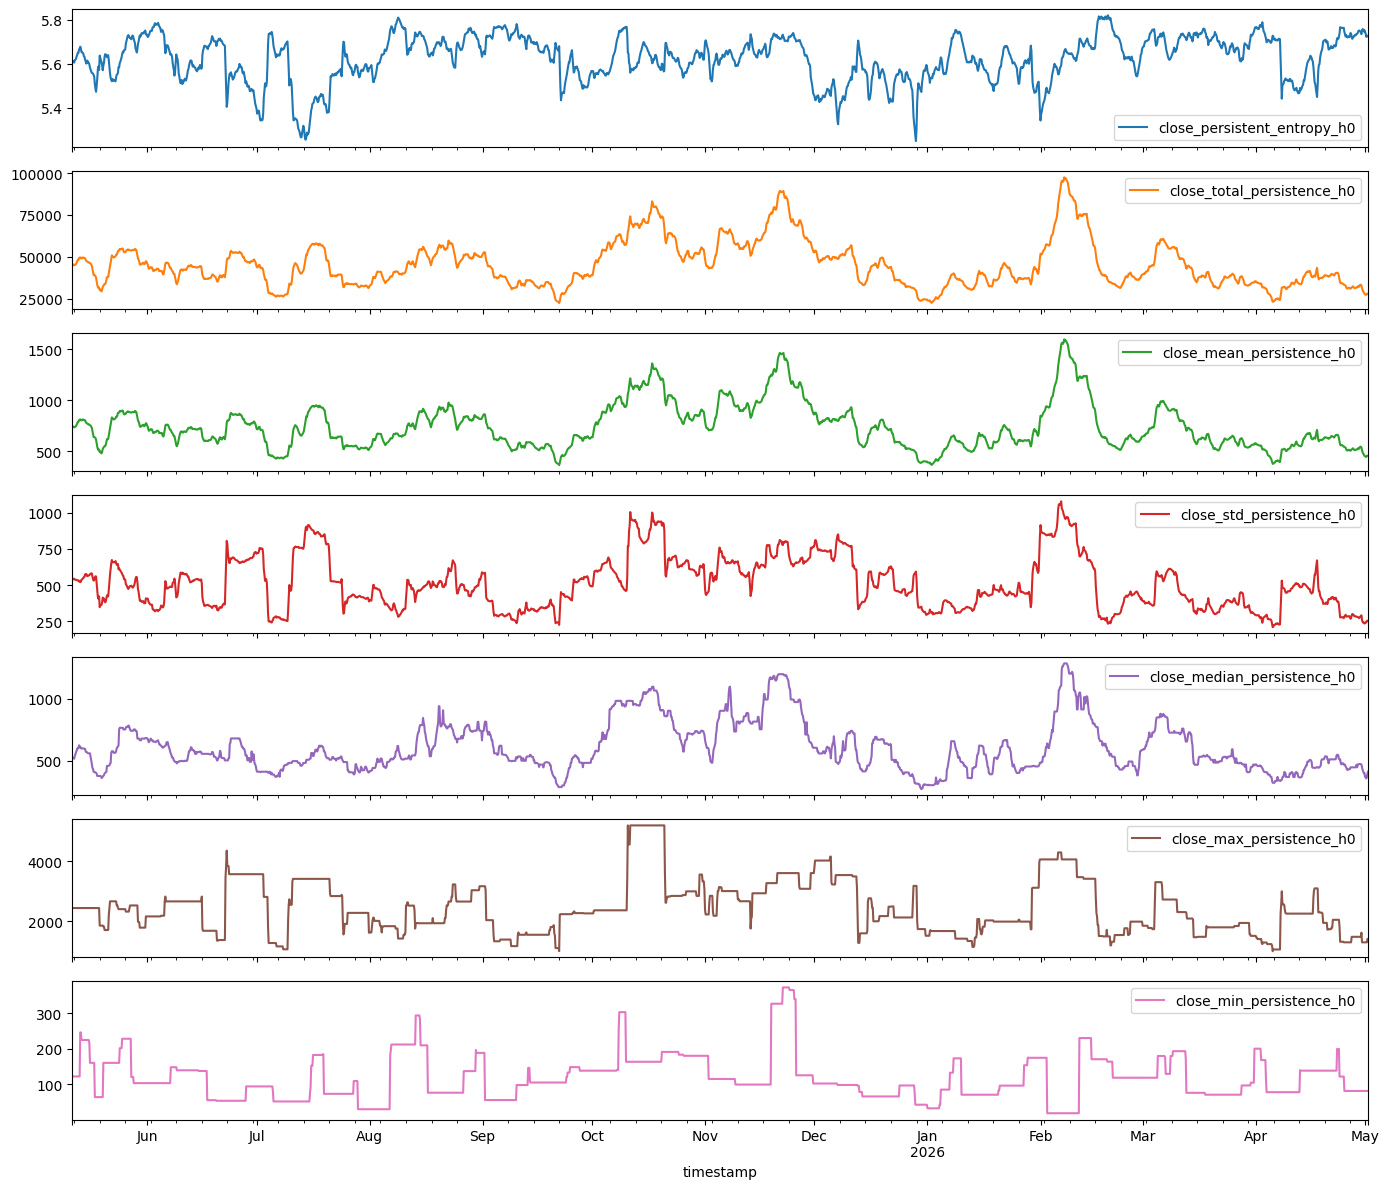

In [128]:
h0_cols = [c for c in tda_df.columns if "h0" in c.lower()]

tda_df[h0_cols].plot(
    subplots=True,
    figsize=(14, 12),
    sharex=True
)

plt.tight_layout()
plt.show()

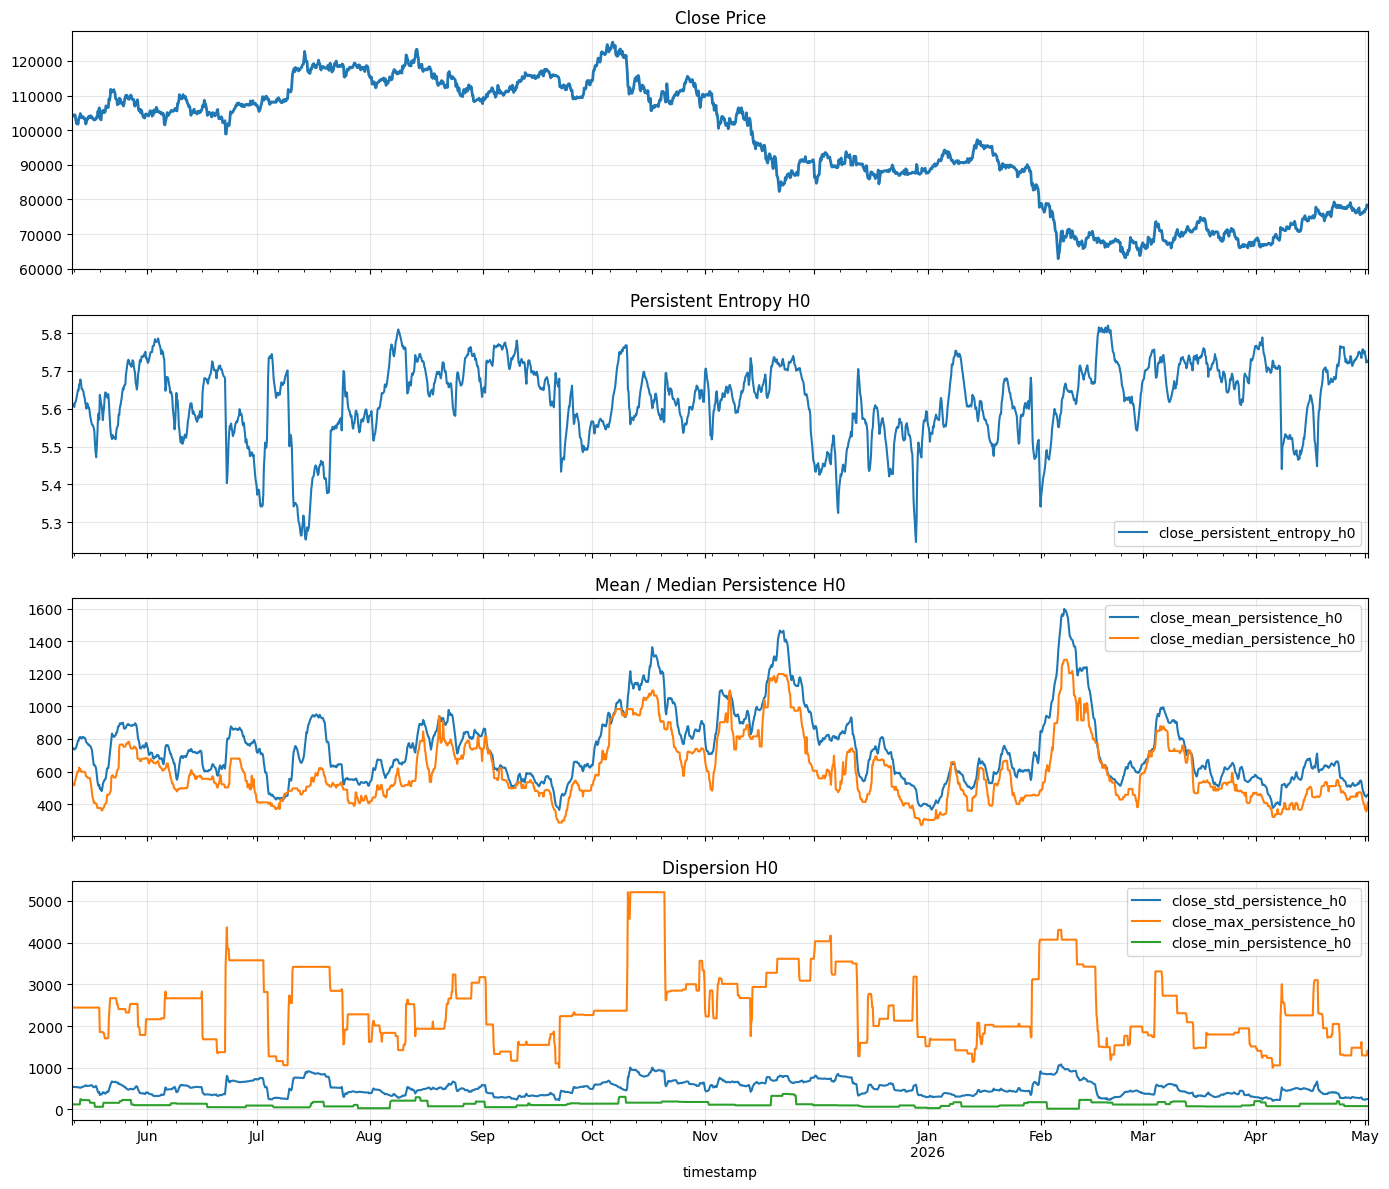

In [129]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True
)

tda_df["close"].plot(
    ax=axes[0],
    title="Close Price",
    linewidth=2
)

entropy_cols = [
    "close_persistent_entropy_h0",
]

tda_df[entropy_cols].plot(
    ax=axes[1],
    title="Persistent Entropy H0"
)

central_cols = [
    "close_mean_persistence_h0",
    "close_median_persistence_h0",
]

tda_df[central_cols].plot(
    ax=axes[2],
    title="Mean / Median Persistence H0"
)

dispersion_cols = [
    "close_std_persistence_h0",
    "close_max_persistence_h0",
    "close_min_persistence_h0",
]

tda_df[dispersion_cols].plot(
    ax=axes[3],
    title="Dispersion H0"
)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [130]:
def plot_tda_dashboard(
    df,
    homology="h0",
    start=None,
    end=None,
    price_col="close",
    figsize=(14, 14),
):
    """
    Dashboard compacto para visualizar features TDA
    por grupo de homología (h0, h1, h2, ...).
    """

    plot_df = df.copy()

    if start is not None:
        plot_df = plot_df.loc[start:]

    if end is not None:
        plot_df = plot_df.loc[:end]

    homology = homology.lower()

    h_cols = [
        c for c in plot_df.columns
        if homology in c.lower()
    ]

    if len(h_cols) == 0:
        raise ValueError(
            f"No se encontraron columnas para {homology}"
        )

    entropy_cols = [
        c for c in h_cols
        if "entropy" in c.lower()
    ]

    central_cols = [
        c for c in h_cols
        if (
            "mean" in c.lower()
            or "median" in c.lower()
        )
    ]

    dispersion_cols = [
        c for c in h_cols
        if (
            "std" in c.lower()
            or "max" in c.lower()
            or "min" in c.lower()
        )
    ]

    total_cols = [
        c for c in h_cols
        if "total_persistence" in c.lower()
    ]

    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        5, 1,
        height_ratios=[3, 1, 1, 1, 1]
    )

    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    ax3 = fig.add_subplot(gs[3], sharex=ax0)
    ax4 = fig.add_subplot(gs[4], sharex=ax0)

    plot_df[price_col].plot(
        ax=ax0,
        title=f"{price_col.upper()}",
        linewidth=2
    )

    if entropy_cols:
        plot_df[entropy_cols].plot(
            ax=ax1,
            title=f"Entropy {homology.upper()}"
        )

    if total_cols:
        plot_df[total_cols].plot(
            ax=ax2,
            title=f"Total Persistence {homology.upper()}"
        )

    if central_cols:
        plot_df[central_cols].plot(
            ax=ax3,
            title=f"Centrality {homology.upper()}"
        )

    if dispersion_cols:
        plot_df[dispersion_cols].plot(
            ax=ax4,
            title=f"Dispersion {homology.upper()}"
        )

    for ax in [ax0, ax1, ax2, ax3, ax4]:
        ax.grid(True, alpha=0.3)

        if len(ax.lines) > 0:
            ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

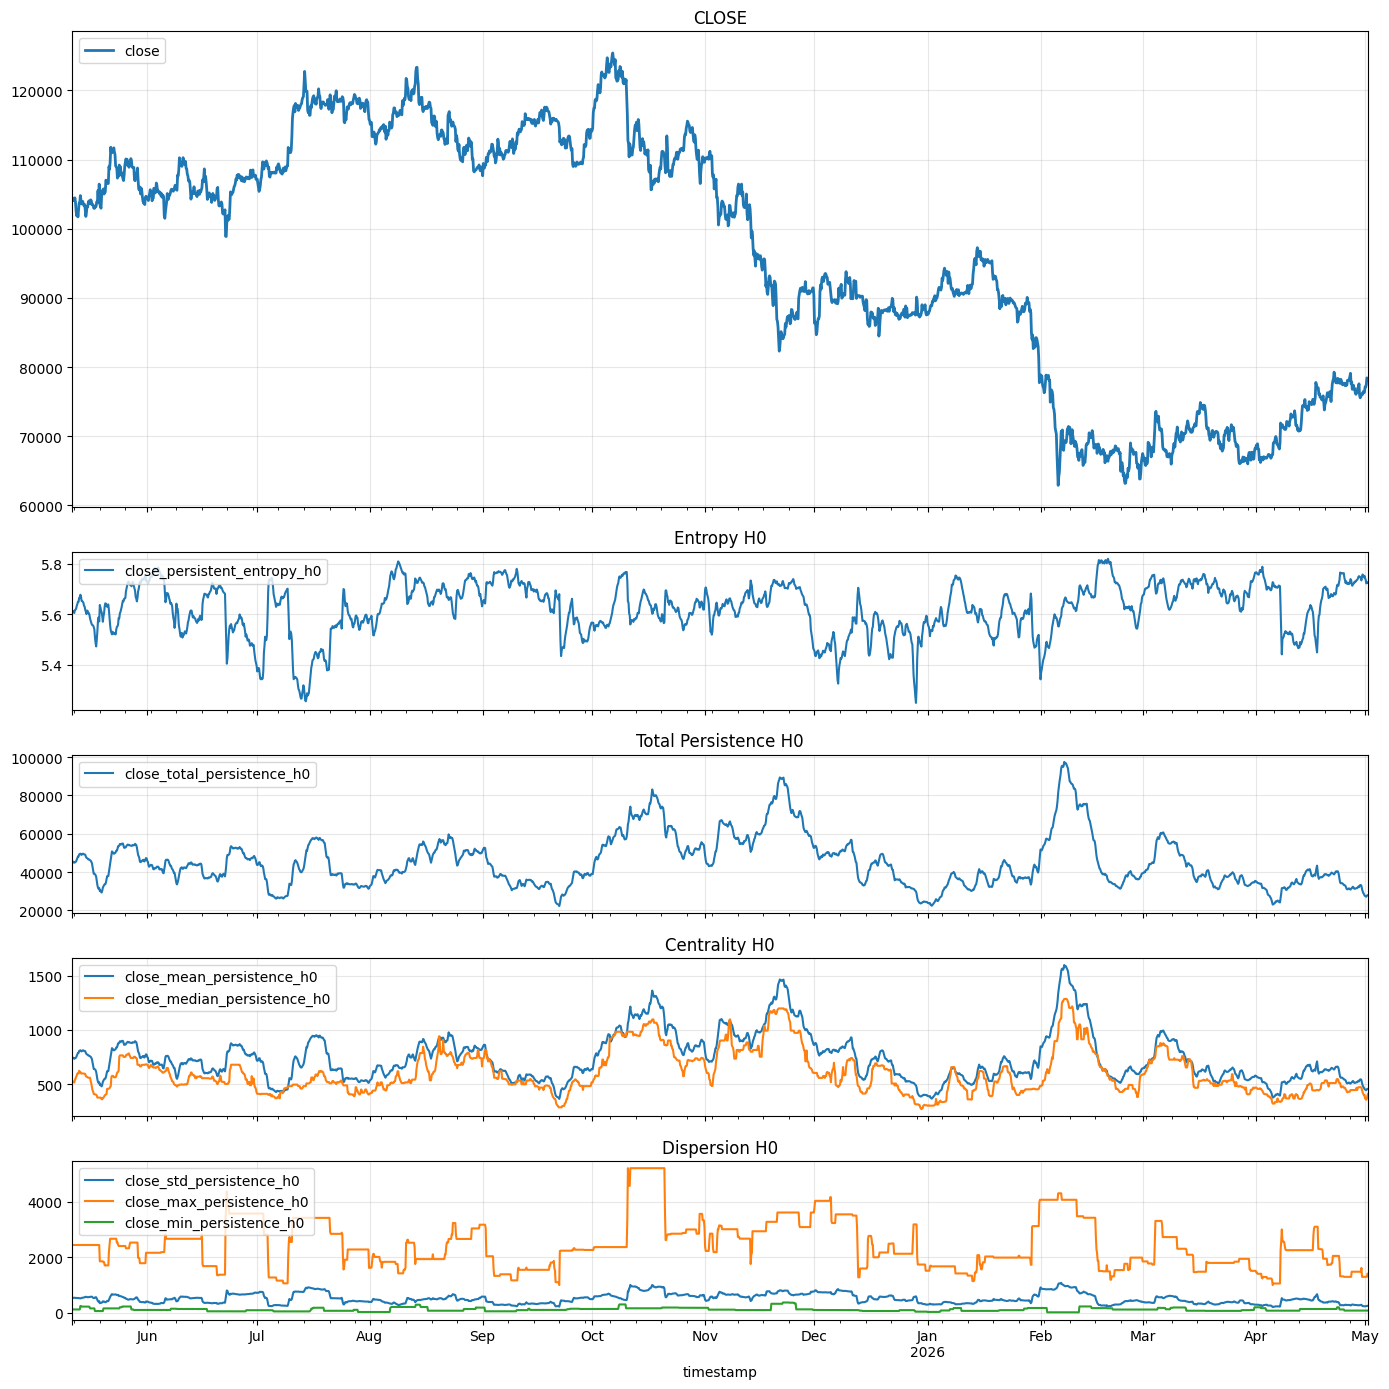

In [131]:
plot_tda_dashboard(
    df=tda_df, 
    homology="h0",
)

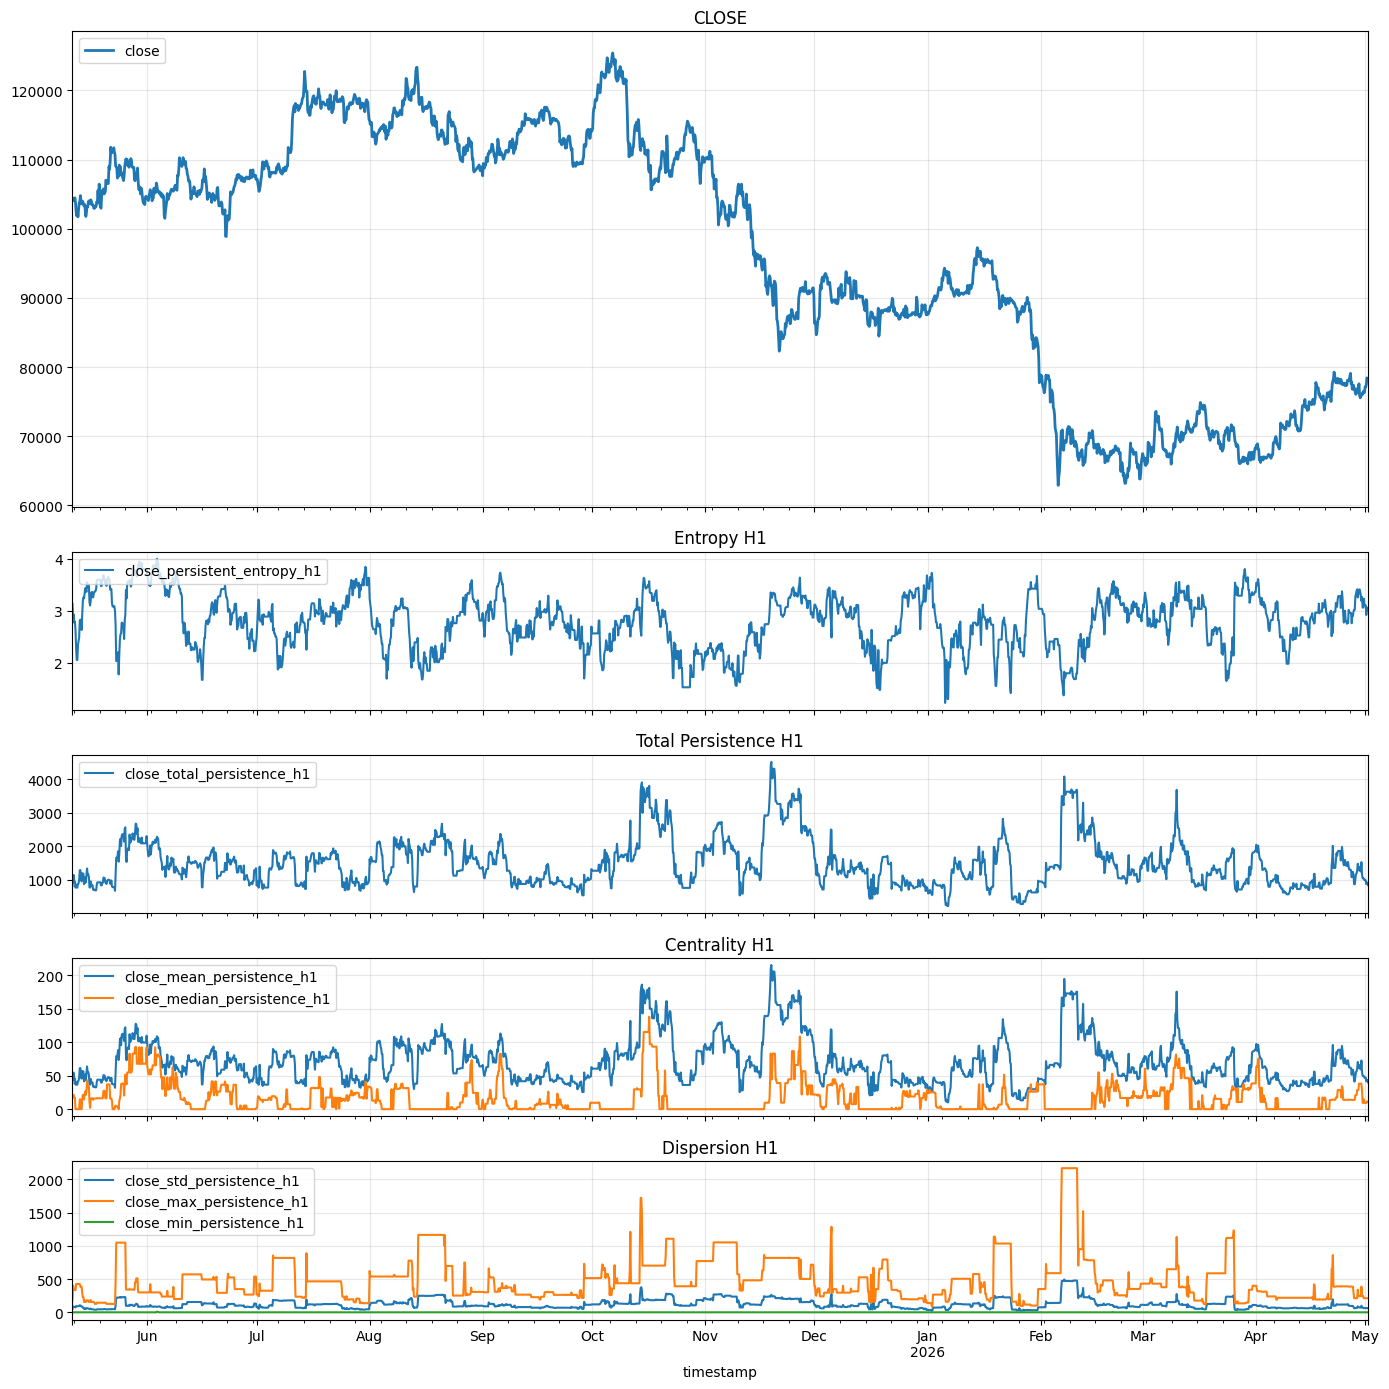

In [132]:
plot_tda_dashboard(
    df=tda_df, 
    homology="h1",
)

In [133]:
f.close()